### Results
Reads the CSV files written by `src/main.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
res = pd.read_csv('../results/results.csv')
bins = pd.read_csv('../results/reliability.csv')
cost = pd.read_csv('../results/cost.csv')
MODELS = ['rf', 'cnn', 'resnet', 'wav2vec']
DATASETS = ['esc10', 'sc', 'sc_small']
res.head()

,dataset,model,seed,condition,acc,f1,ece,nll,overconf,ece_ts,temperature
0,esc10,rf,0,clean,0.7825,0.779331,0.298062,0.902006,-0.295196,0.035925,0.373309
1,esc10,rf,0,white_20,0.6125,0.586555,0.229736,1.322461,-0.229736,0.065884,0.373309
2,esc10,rf,0,white_10,0.3550,0.282775,0.082634,1.947314,0.015114,0.291713,0.373309
3,esc10,rf,0,white_0,0.1700,0.094135,0.267897,3.521557,0.267897,0.547809,0.373309
4,esc10,rf,0,real_20,0.6525,0.620960,0.261153,1.230598,-0.261153,0.058744,0.373309


#### 1. Clean comparison

In [2]:
res[res.condition == 'clean'].pivot(index='model', columns='dataset', values=['acc', 'f1']).reindex(MODELS).round(3)

acc                     f1                
dataset  esc10     sc sc_small  esc10     sc sc_small
model                                                
rf       0.782  0.633    0.416  0.779  0.632    0.410
cnn      0.832  0.970    0.598  0.832  0.970    0.588
resnet   0.872  0.980    0.494  0.873  0.980    0.492
wav2vec  0.822  0.984    0.950  0.819  0.984    0.950

#### 2. Cost

In [3]:
cost.groupby(['dataset', 'model'])[['params', 'train_seconds', 'latency_ms']].mean().round(1)

params  train_seconds  latency_ms
dataset  model                                         
esc10    cnn        242250.0           27.2         5.3
         resnet   11181642.0           42.8         9.4
         rf              0.0            0.5        21.3
         wav2vec  94379402.0          740.5       160.3
sc       cnn        242250.0          493.5         1.5
         resnet   11181642.0          948.0         5.9
         rf              0.0           38.4        17.1
         wav2vec  94379402.0         5617.7        40.7
sc_small cnn        242250.0            9.0         1.6
         resnet   11181642.0           14.8         5.2
         rf              0.0            0.4        20.2
         wav2vec  94379402.0          119.1        41.7

#### 3 and 4. Accuracy, ECE and overconfidence against noise level

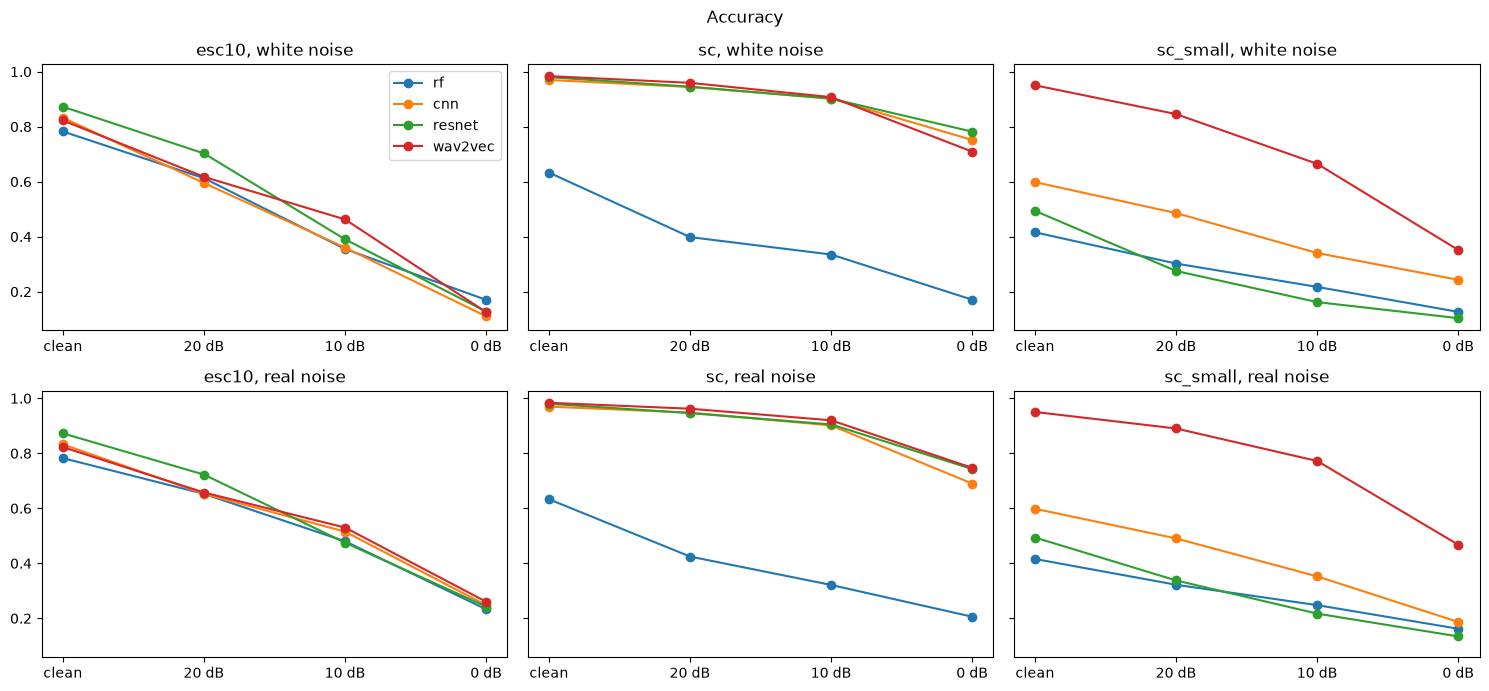

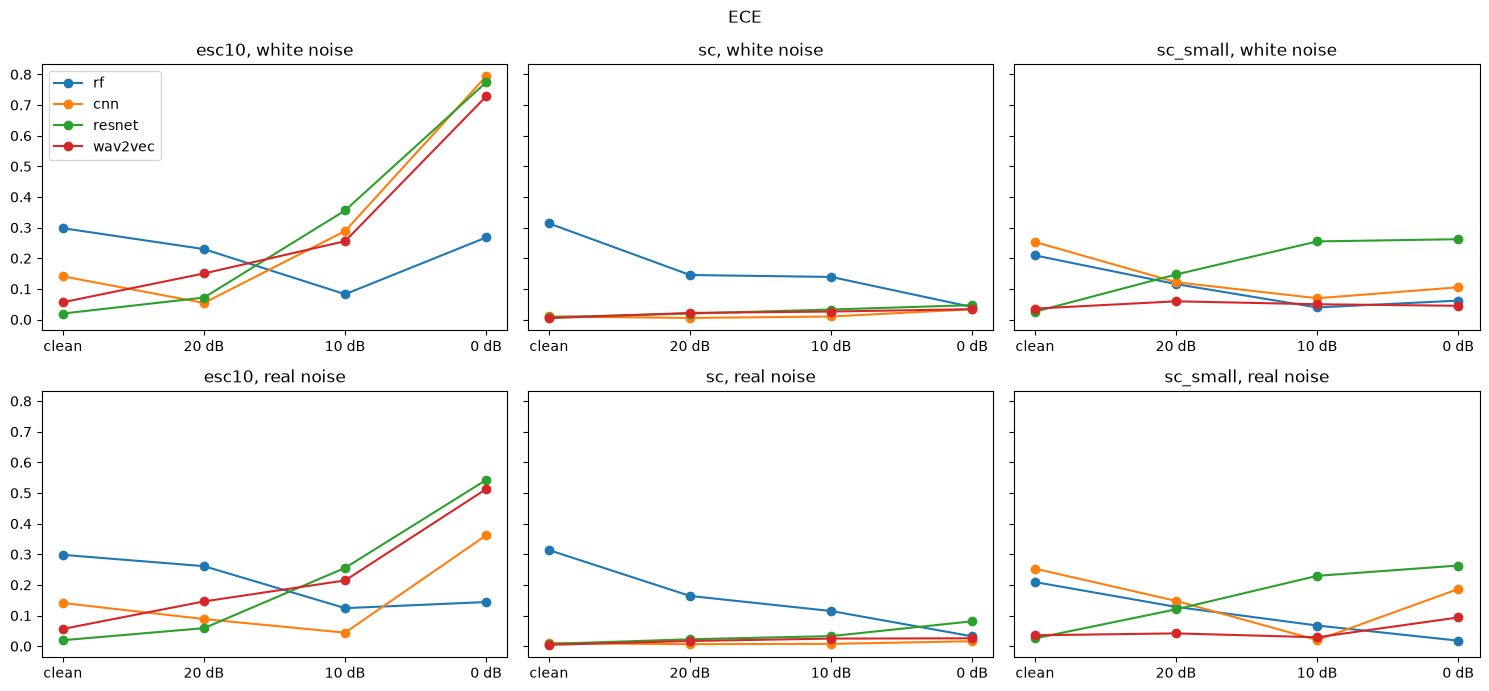

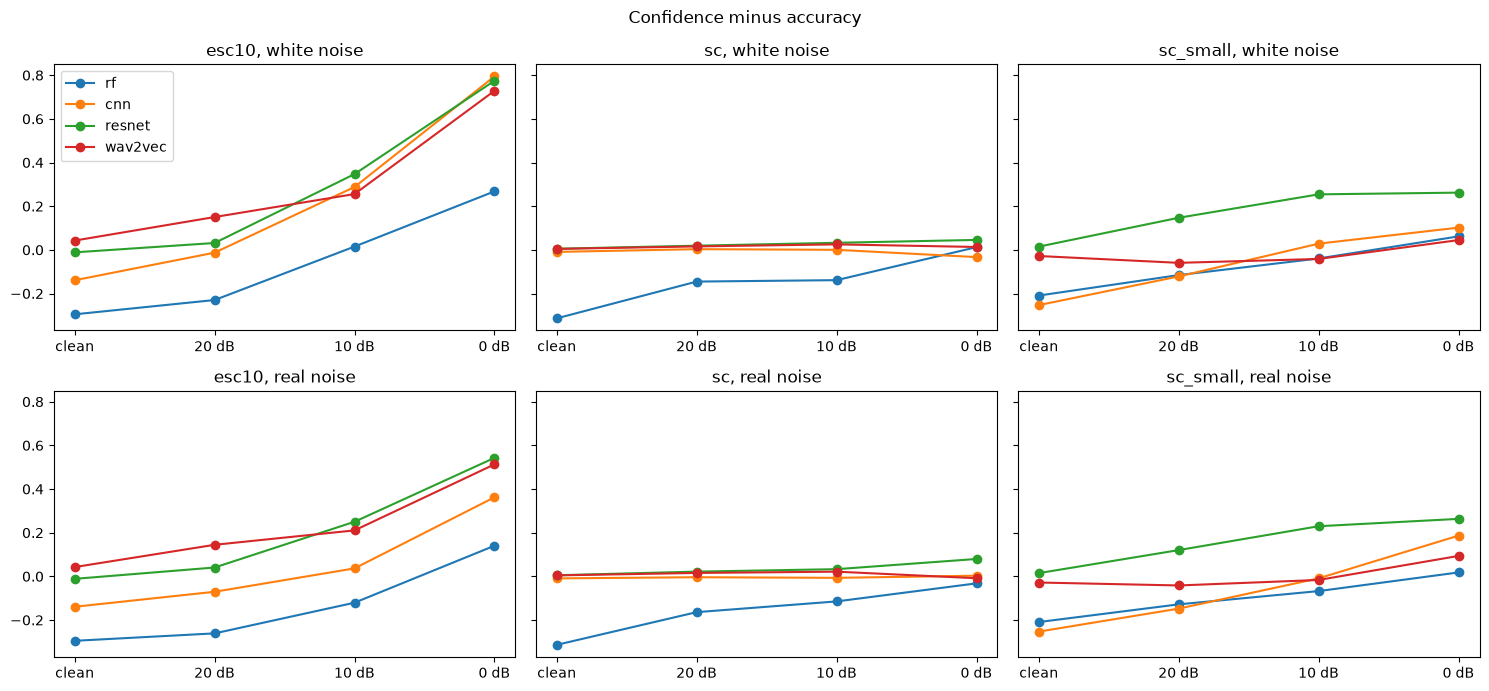

In [4]:
def curves(metric, title):
    fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
    for row, kind in enumerate(['white', 'real']):
        conditions = ['clean'] + [f'{kind}_{s}' for s in [20, 10, 0]]
        for col, dataset in enumerate(DATASETS):
            ax = axes[row, col]
            for model in MODELS:
                part = res[(res.dataset == dataset) & (res.model == model)].set_index('condition')
                if all(c in part.index for c in conditions):
                    ax.plot(['clean', '20 dB', '10 dB', '0 dB'], part.loc[conditions, metric], marker='o', label=model)
            ax.set_title(f'{dataset}, {kind} noise')
    axes[0, 0].legend(); fig.suptitle(title); plt.tight_layout(); plt.show()

curves('acc', 'Accuracy')
curves('ece', 'ECE')
curves('overconf', 'Confidence minus accuracy')

#### 5. Temperature scaling: ECE before and after

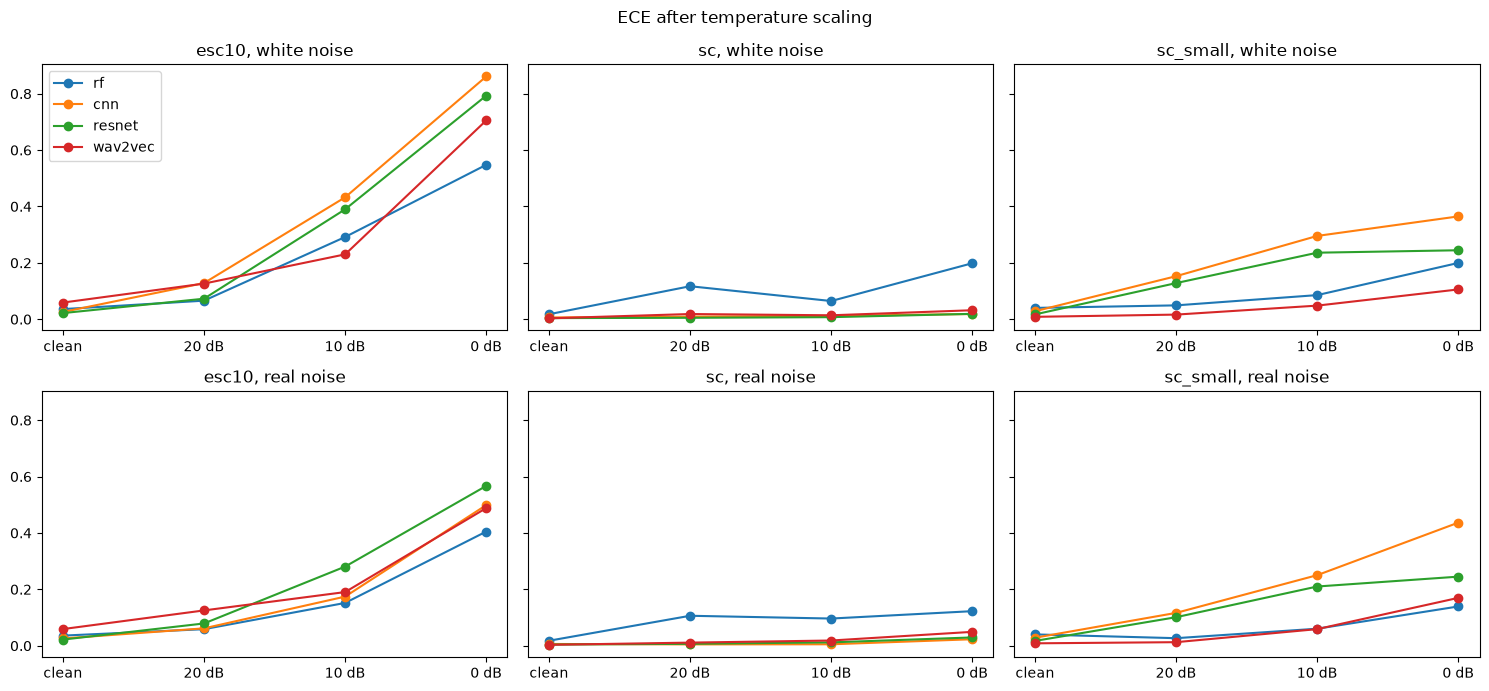

ece                ece_ts               
condition         clean real_0 white_0  clean real_0 white_0
dataset  model                                              
esc10    cnn      0.141  0.362   0.794  0.026  0.499   0.861
         resnet   0.020  0.543   0.774  0.022  0.567   0.793
         rf       0.298  0.144   0.268  0.036  0.405   0.548
         wav2vec  0.056  0.513   0.728  0.059  0.488   0.705
sc       cnn      0.010  0.016   0.033  0.006  0.023   0.019
         resnet   0.007  0.081   0.047  0.004  0.029   0.019
         rf       0.314  0.032   0.041  0.018  0.123   0.199
         wav2vec  0.004  0.026   0.034  0.003  0.049   0.032
sc_small cnn      0.253  0.187   0.105  0.028  0.437   0.365
         resnet   0.026  0.263   0.262  0.017  0.245   0.245
         rf       0.209  0.018   0.062  0.040  0.139   0.200
         wav2vec  0.036  0.094   0.045  0.009  0.170   0.106

In [5]:
curves('ece_ts', 'ECE after temperature scaling')
res[res.condition.isin(['clean', 'white_0', 'real_0'])].pivot_table(index=['dataset', 'model'], columns='condition', values=['ece', 'ece_ts']).round(3)

#### Reliability diagrams

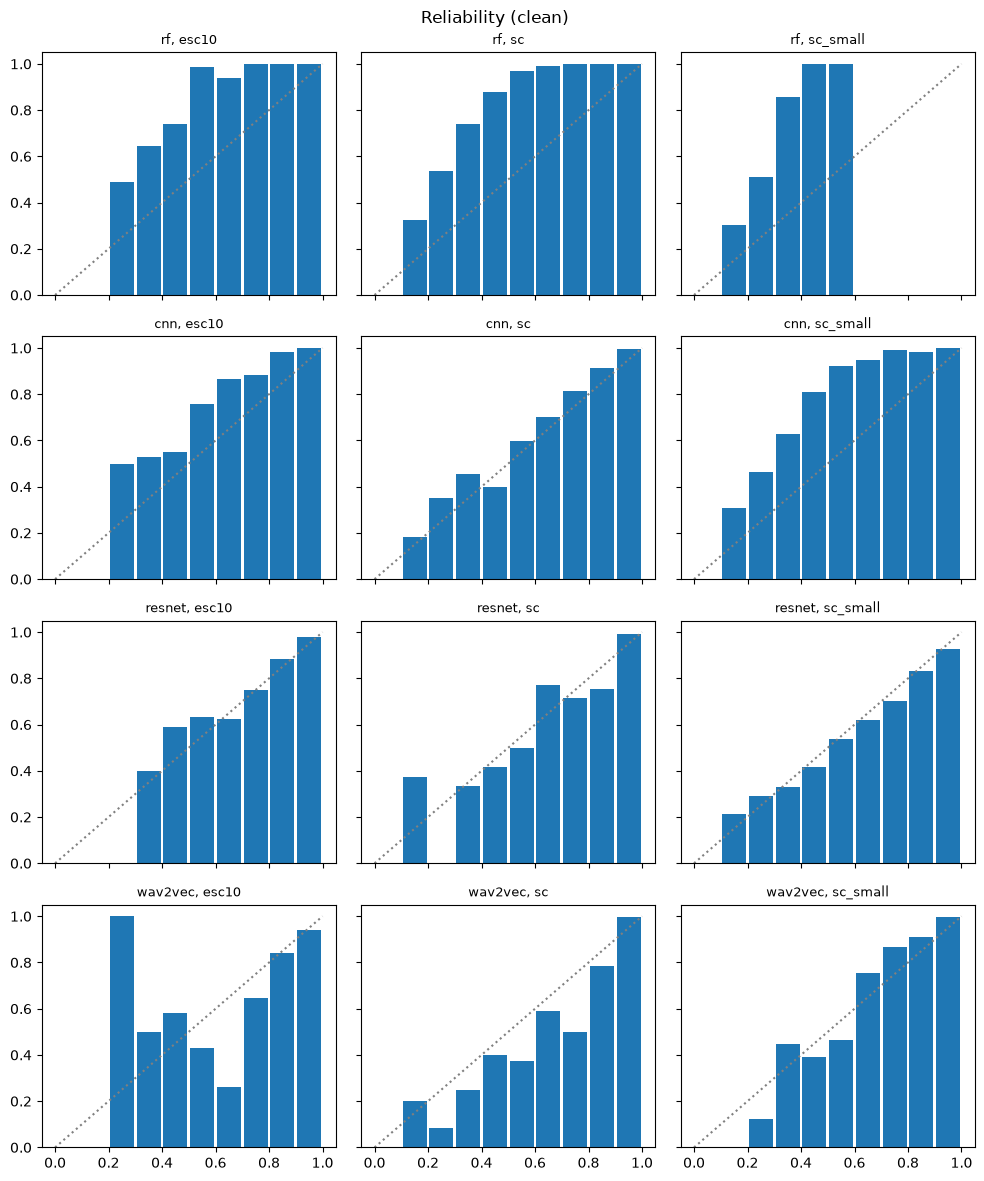

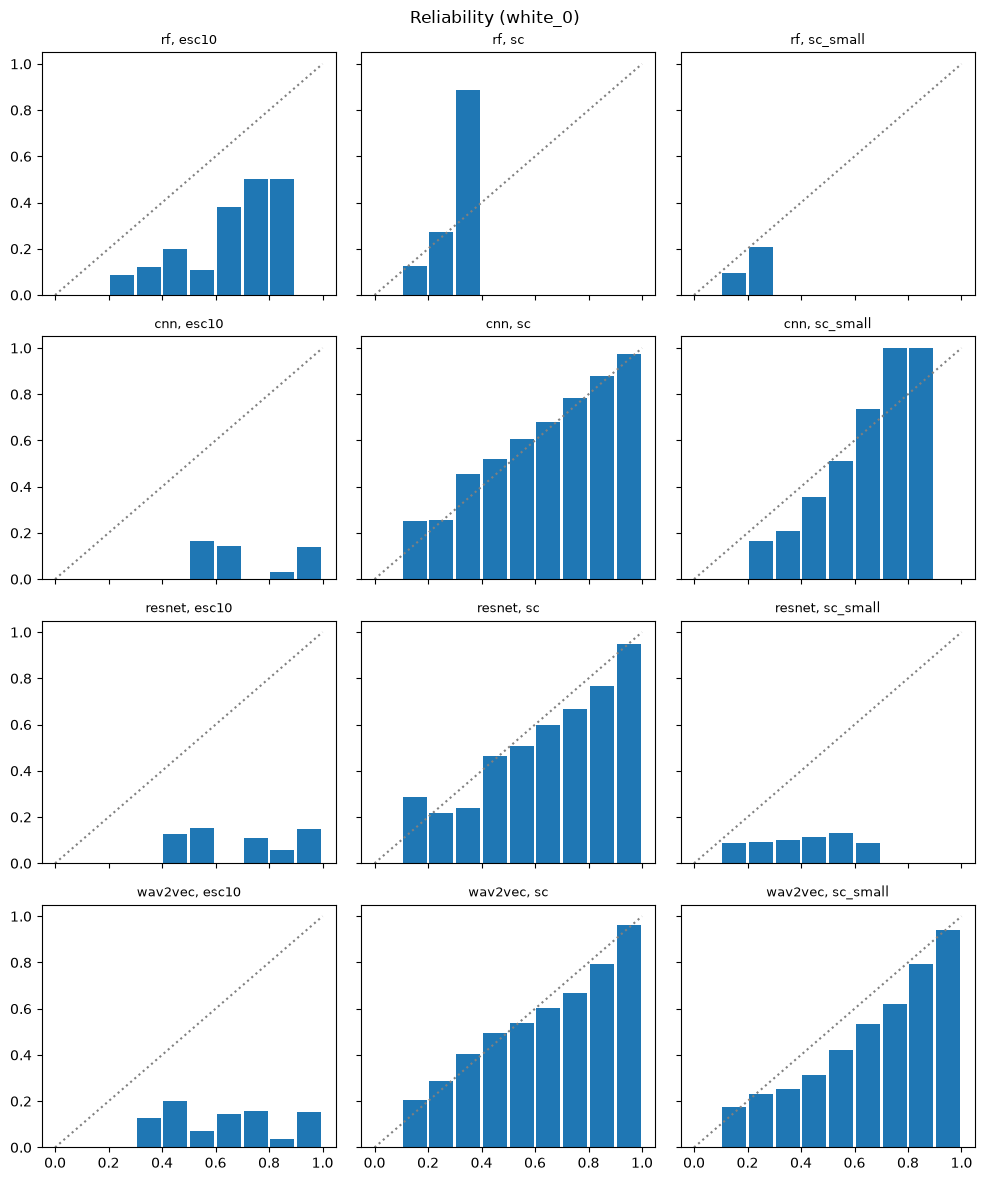

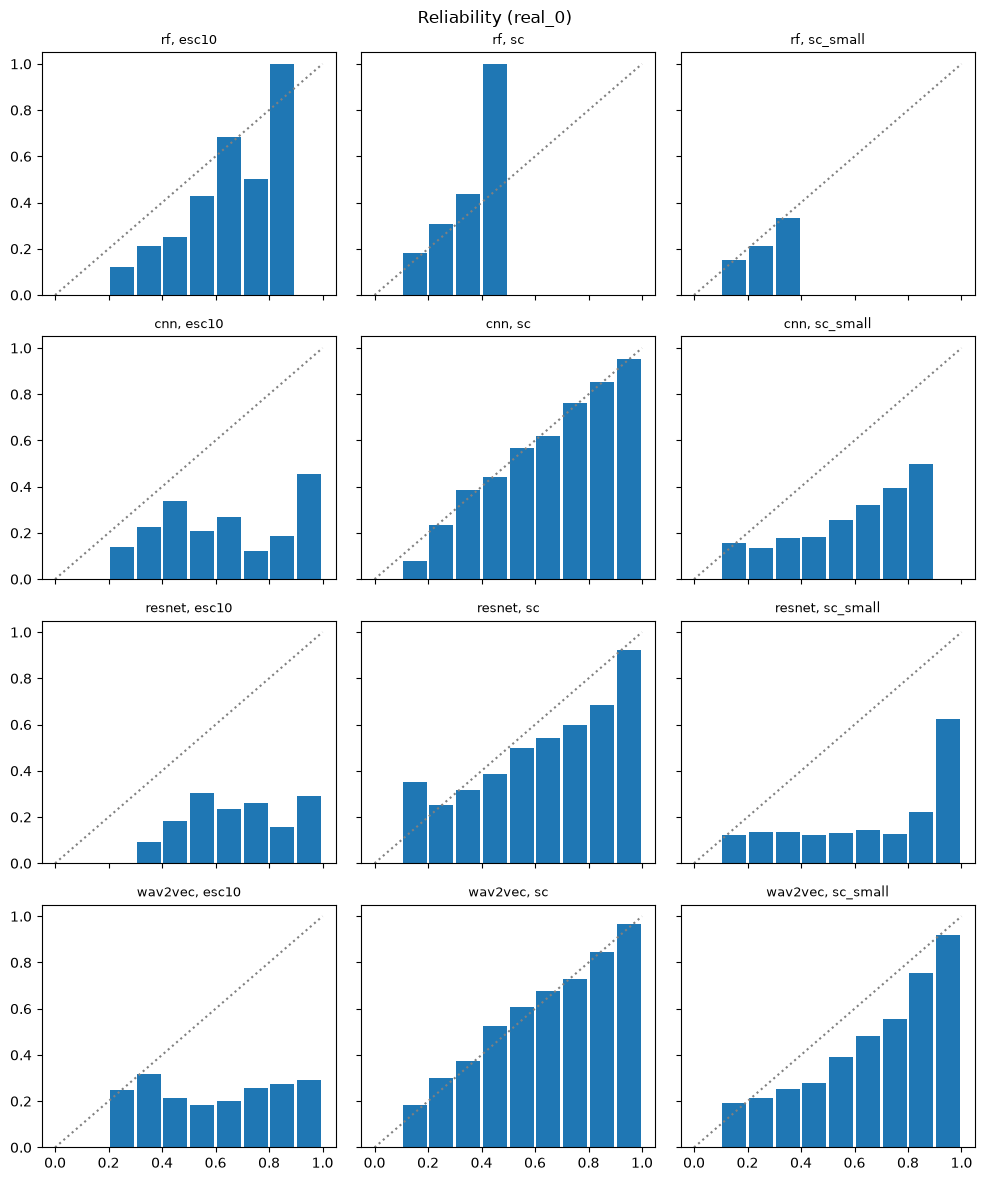

In [6]:
for condition in ['clean', 'white_0', 'real_0']:
    fig, axes = plt.subplots(len(MODELS), 3, figsize=(10, 3 * len(MODELS)), sharex=True, sharey=True)
    for i, model in enumerate(MODELS):
        for j, dataset in enumerate(DATASETS):
            part = bins[(bins.dataset == dataset) & (bins.model == model) & (bins.condition == condition)]
            ax = axes[i, j]
            ax.plot([0, 1], [0, 1], ':', color='gray')
            ax.bar((part.bin + 0.5) / 10, part.accuracy.fillna(0), width=0.09)
            ax.set_title(f'{model}, {dataset}', fontsize=9)
    fig.suptitle(f'Reliability ({condition})'); plt.tight_layout(); plt.show()